# Corneal permeability model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px

import rdkit
from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors, AllChem, Descriptors, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import classification_report

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_curve, auc, roc_auc_score, accuracy_score

## Load dataset

In [2]:
df = pd.read_csv('corneal_raw.csv', usecols=[0,3])
df.head()

,smiles,logP
0,C1=CC(=CC=C1S(=O)(=O)N)Cl,-4.26
1,CNS(=O)(=O)C1=CC=C(C=C1)Cl,-4.19
2,CCCC(=O)NC1=CC(=C(C=C1)OCC(CNC(C)C)O)C(=O)C,-6.06
3,CC(=O)NC1=NN=C(S1)S(=O)(=O)N,-6.24
4,CC(C)NCC(COC1=CC=CC=C1CC=C)O,-4.54


### Dataset provenance

The corneal permeability dataset combines **5 independent ex vivo (rabbit cornea) studies**. Below we quantify how many compounds come from each source and check for cross-study duplicates.

In [4]:
df_full = pd.read_csv('corneal_raw.csv')
print('Total rows:', len(df_full))
print('Duplicated SMILES:', df_full['smiles'].duplicated().sum())
print()
print('Compounds per source study:')
print(df_full['title'].value_counts())


Total rows: 163
Duplicated SMILES: 1

Compounds per source study:
title
Permeability of cornea, sclera, and conjunctiva: a literature analysis for drug delivery to the eye        89
Prediction of corneal permeability using artificial neural networks                                        45
Corneal and conjunctival drug permeability: Systematic comparison and pharmacokinetic impact in the eye    14
Quantitative and qualitative prediction of corneal permeability for drug-like compounds                     8
Prediction of the Corneal Permeability of Drug-Like Compounds                                               7
Name: count, dtype: int64


In [5]:
# remove exact duplicate (same compound reported in two review papers with identical measured value)
df_full = df_full.drop_duplicates(subset='smiles').reset_index(drop=True)
print('Unique compounds used for modelling:', len(df_full))

Unique compounds used for modelling: 162


## Statistic

/var/folders/d0/t960n9f12vv86tmxqy62k3r40000gn/T/ipykernel_23038/4158815471.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['logP'], hist=True, kde=True,


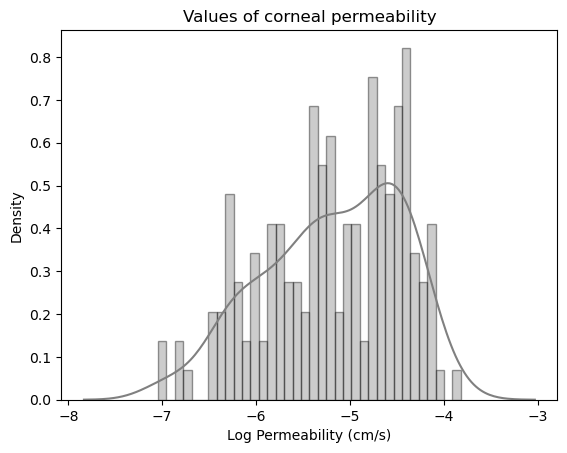

In [6]:
sns.distplot(df['logP'], hist=True, kde=True, 
             bins=int(180/5), color = 'gray',
             hist_kws={'edgecolor':'black'})
plt.title('Values of corneal permeability')
plt.xlabel('Log Permeability (cm/s)')
plt.show()

In [7]:
median = np.median(df['logP'])
median

np.float64(-5.130768280269024)

In [8]:
active = df[df['logP'] >= -5.13]
inactive = df[df['logP'] < -5.13]

In [9]:
active.shape

(81, 2)

### Is a median split the right choice? 

There is no single, universally accepted absolute cutoff for "high" vs "low" corneal permeability in the ophthalmic literature — reported ex vivo Papp values for approved/investigated compounds span roughly 0.7–110 &times;10<sup>-7</sup> cm/s depending on assay conditions, species/tissue prep, and lab. Because our dataset pools 5 heterogeneous sources, importing an absolute threshold from any single source paper would not be well justified.

We therefore keep the **median split**, which (a) guarantees balanced classes for a small dataset (n=162, critical for a 4:1 train/test split) and (b) is a standard, defensible choice in QSAR modelling when no absolute clinically-anchored cutoff exists.

To make sure this choice is not fragile, we check how model performance changes if the threshold is shifted away from the median.

In [10]:
descriptor_names = list(rdMolDescriptors.Properties.GetAvailableProperties())
get_descriptors = rdMolDescriptors.Properties(descriptor_names)

def smi_to_descriptors(smile):
    mol = Chem.MolFromSmiles(smile)
    descriptors = []
    if mol:
        descriptors = np.array(get_descriptors.ComputeProperties(mol))
    return descriptors

df_full['descriptors'] = df_full['smiles'].apply(smi_to_descriptors)
X_full = np.stack(df_full['descriptors'])

In [11]:
print(f"Median threshold = {median:.3f}\n")
sensitivity_rows = []
for shift in [-0.4, -0.2, 0.0, 0.2, 0.4]:
    thr = median + shift
    y_shift = (df_full['logP'] >= thr).astype(int).values
    if min(np.bincount(y_shift)) < 10:
        print(f"  shift={shift:+.1f} thr={thr:.2f} -> skipped (class too small)")
        continue
    aucs = []
    for seed in range(5):
        tr, te = train_test_split(np.arange(len(y_shift)), test_size=0.2, random_state=seed, stratify=y_shift)
        m = XGBClassifier(eval_metric='logloss').fit(X_full[tr], y_shift[tr])
        p = m.predict_proba(X_full[te])[:,1]
        aucs.append(roc_auc_score(y_shift[te], p))
    sensitivity_rows.append((shift, thr, y_shift.mean(), np.mean(aucs), np.std(aucs)))
    print(f"  shift={shift:+.1f} thr={thr:.2f} class_balance={y_shift.mean():.2f} -> AUC mean={np.mean(aucs):.3f} std={np.std(aucs):.3f}")

sens_df = pd.DataFrame(sensitivity_rows, columns=['shift','threshold','pos_class_frac','auc_mean','auc_std'])
sens_df

Median threshold = -5.131

  shift=-0.4 thr=-5.53 class_balance=0.69 -> AUC mean=0.843 std=0.047
  shift=-0.2 thr=-5.33 class_balance=0.59 -> AUC mean=0.805 std=0.071
  shift=+0.0 thr=-5.13 class_balance=0.50 -> AUC mean=0.853 std=0.089
  shift=+0.2 thr=-4.93 class_balance=0.43 -> AUC mean=0.917 std=0.053
  shift=+0.4 thr=-4.73 class_balance=0.33 -> AUC mean=0.936 std=0.035


,shift,threshold,pos_class_frac,auc_mean,auc_std
0,-0.4,-5.530768,0.691358,0.843478,0.046585
1,-0.2,-5.330768,0.592593,0.805385,0.071277
2,0.0,-5.130768,0.500000,0.852941,0.089210
3,0.2,-4.930768,0.425926,0.917293,0.052524
4,0.4,-4.730768,0.327160,0.936364,0.034730


**Conclusion:** performance stays in a reasonable range (AUC 0.80–0.94) across a ±0.4 log-unit shift of the threshold — the median split is not a fragile, cherry-picked choice; it simply corresponds to the point of best class balance for this dataset.

## Descriptor generation

In [12]:
active['descriptors'] = active.smiles.apply(smi_to_descriptors)
inactive['descriptors'] = inactive.smiles.apply(smi_to_descriptors)

In [13]:
active['Class'] = 1

In [14]:
inactive['Class'] = 0

In [15]:
dataset = pd.concat([active, inactive])
dataset.head()

,smiles,logP,descriptors,Class
0,C1=CC(=CC=C1S(=O)(=O)N)Cl,-4.26,"[190.980777112, 191.63899999999998, 3.0, 2.0, ...",1
1,CNS(=O)(=O)C1=CC=C(C=C1)Cl,-4.19,"[204.996427176, 205.666, 3.0, 1.0, 2.0, 1.0, 2...",1
4,CC(C)NCC(COC1=CC=CC=C1CC=C)O,-4.54,"[249.172878976, 249.35399999999998, 3.0, 2.0, ...",1
6,CC(C)NCC(COC1=CC=C(C=C1)CCOCC2CC2)O,-4.57,"[307.214743788, 307.434, 4.0, 2.0, 11.0, 2.0, ...",1
7,CC1=CC(=CC=C1)OCC(CNCCC2=CC(=C(C=C2)OC)OC)O,-4.24,"[345.19400834399994, 345.4390000000001, 5.0, 2...",1


In [16]:
X = np.stack(dataset['descriptors'])
y = dataset['Class']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

## Train model (baseline: random split)

In [18]:
model = XGBClassifier().fit(X_train, y_train)
preds = model.predict(X_test)

In [19]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 6, 7],
    "learning_rate": [0.01, 0.1, 0.2, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

In [20]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [21]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=0,
    n_jobs=-1
)

In [22]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Sup

In [23]:
best_xgb = grid_search.best_estimator_

In [24]:
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91        16
           1       0.94      0.88      0.91        17

    accuracy                           0.91        33
   macro avg       0.91      0.91      0.91        33
weighted avg       0.91      0.91      0.91        33



In [25]:
from sklearn.model_selection import cross_val_score
base = cross_val_score(
    XGBClassifier(eval_metric='logloss', random_state=42),
    X_train, y_train, scoring='f1', cv=cv,
).mean()
print(f"default CV F1 = {base:.3f}   tuned CV F1 = {grid_search.best_score_:.3f}")

default CV F1 = 0.779   tuned CV F1 = 0.814


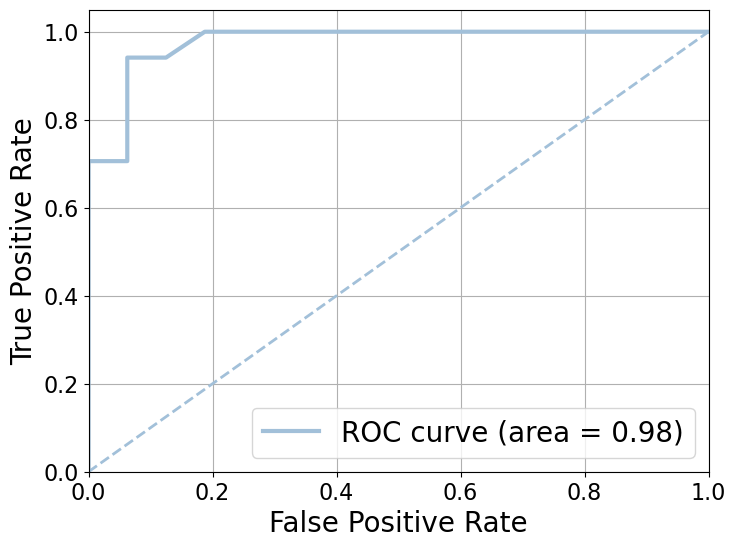

In [26]:
y_pred = best_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr, 
    color='#A2C0D9', 
    label='ROC curve (area = {:.2f})'.format(roc_auc),
    linewidth=3
)

plt.plot(
    [0, 1], [0, 1], 
    color='#A2C0D9', 
    linestyle='--', 
    linewidth=2
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=20)
plt.ylabel('True Positive Rate', fontsize=20)
plt.legend(loc='lower right', fontsize=20)
plt.tick_params(axis='both', labelsize=16)

plt.grid()
plt.savefig('cor_ML.svg', dpi=700, bbox_inches='tight')
plt.show()

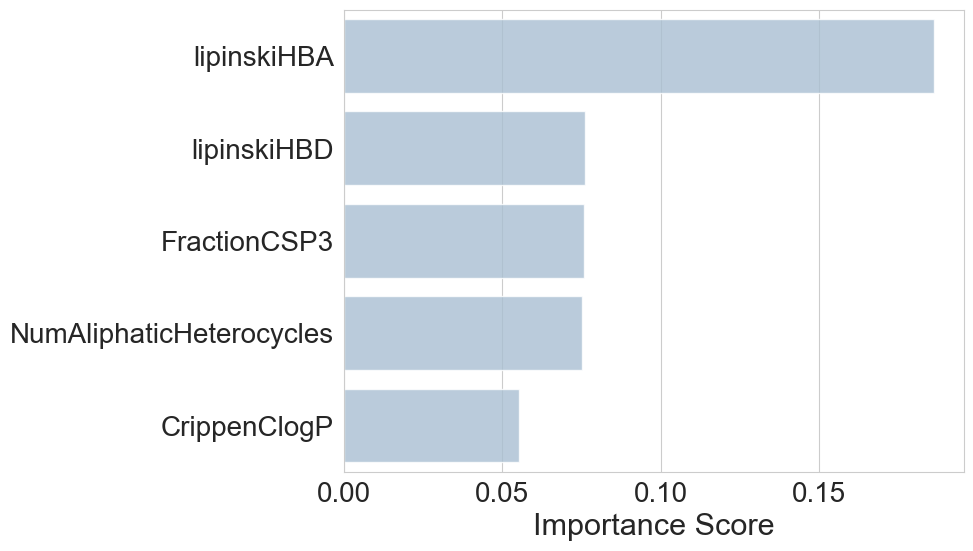

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

feature_importance_df = pd.DataFrame({
    'Feature': descriptor_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top5_df = feature_importance_df.head(5)

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

bar_color = '#A2C0D9'
sns.barplot(x='Importance', y='Feature', data=top5_df, color=bar_color, alpha=0.8)

plt.xlabel('Importance Score', fontsize=22)
plt.ylabel('')

plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.savefig('corr_FI.svg', dpi=700, bbox_inches='tight')
plt.show()

## Save model

In [29]:
import joblib
joblib.dump(model, 'best_model_corneal.pkl')

['best_model_corneal.pkl']

## Robustness under scaffold splitting 

In [114]:
def morgan_fp(smi, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)

def scaffold_of(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf)
    except Exception:
        return None

def scaffold_split(smiles_list, test_size=0.2, seed=42):
    """Group compounds by Murcko scaffold; assign whole scaffold groups to
    train/test (largest groups to train first) to approximate test_size."""
    scaffolds = {}
    for idx, smi in enumerate(smiles_list):
        s = scaffold_of(smi)
        scaffolds.setdefault(s, []).append(idx)
    groups = list(scaffolds.values())
    rng = np.random.RandomState(seed)
    order = rng.permutation(len(groups))
    groups = [groups[i] for i in order]
    groups.sort(key=len, reverse=True)
    n_total = len(smiles_list)
    n_test_target = int(round(n_total * test_size))
    test_idx, train_idx = [], []
    for g in groups:
        if len(test_idx) < n_test_target:
            test_idx.extend(g)
        else:
            train_idx.extend(g)
    return np.array(train_idx), np.array(test_idx)

def nn_tanimoto_stats(train_smiles, test_smiles):
    train_fps = [morgan_fp(s) for s in train_smiles]
    train_fps = [f for f in train_fps if f is not None]
    sims = []
    for s in test_smiles:
        fp = morgan_fp(s)
        if fp is None or len(train_fps) == 0:
            continue
        bulk = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        sims.append(max(bulk))
    sims = np.array(sims)
    return {
        'mean_NN_Tanimoto': float(np.mean(sims)) if len(sims) else np.nan,
        'median_NN_Tanimoto': float(np.median(sims)) if len(sims) else np.nan,
        'frac_test_with_NN>0.85': float(np.mean(sims > 0.85)) if len(sims) else np.nan,
        'frac_test_with_NN>0.4': float(np.mean(sims > 0.4)) if len(sims) else np.nan,
    }

In [115]:
smiles_arr = df_full['smiles'].values
y_full = (df_full['logP'] >= median).astype(int).values

def eval_split(train_idx, test_idx, label, verbose=True):
    Xtr, Xte, ytr, yte = X_full[train_idx], X_full[test_idx], y_full[train_idx], y_full[test_idx]
    m = XGBClassifier(eval_metric='logloss').fit(Xtr, ytr)
    proba = m.predict_proba(Xte)[:,1]
    pred = m.predict(Xte)
    auc_ = roc_auc_score(yte, proba)
    f1_ = f1_score(yte, pred)
    acc_ = accuracy_score(yte, pred)
    sims = nn_tanimoto_stats(smiles_arr[train_idx], smiles_arr[test_idx])
    if verbose:
        print(f"--- {label} ---")
        print(f"  n_train={len(train_idx)} n_test={len(test_idx)}  train_pos={ytr.mean():.2f} test_pos={yte.mean():.2f}")
        print(f"  ROC-AUC={auc_:.3f}  F1={f1_:.3f}  Acc={acc_:.3f}")
        print(f"  NN-Tanimoto (test->train): mean={sims['mean_NN_Tanimoto']:.3f} median={sims['median_NN_Tanimoto']:.3f}"
              f"  frac>0.85={sims['frac_test_with_NN>0.85']:.2f}  frac>0.4={sims['frac_test_with_NN>0.4']:.2f}")
    return dict(label=label, n_train=len(train_idx), n_test=len(test_idx), auc=auc_, f1=f1_, acc=acc_, **sims)

results = []
idx_full = np.arange(len(df_full))

# Random split, original seed
tr0, te0 = train_test_split(idx_full, test_size=0.2, random_state=10, stratify=y_full)
results.append(eval_split(tr0, te0, "Random split (orig, seed=10)"))

# Random split, 5 seeds for variance
aucs=[]
for seed in range(5):
    tr,te = train_test_split(idx_full, test_size=0.2, random_state=seed, stratify=y_full)
    m = XGBClassifier(eval_metric='logloss').fit(X_full[tr], y_full[tr])
    p = m.predict_proba(X_full[te])[:,1]
    aucs.append(roc_auc_score(y_full[te], p))
print(f"\nRandom split AUC over 5 seeds: mean={np.mean(aucs):.3f} std={np.std(aucs):.3f}  {[round(a,3) for a in aucs]}\n")

# Scaffold split
tr_s, te_s = scaffold_split(smiles_arr, test_size=0.2, seed=42)
results.append(eval_split(tr_s, te_s, "Scaffold split"))

--- Random split (orig, seed=10) ---
  n_train=129 n_test=33  train_pos=0.50 test_pos=0.52
  ROC-AUC=0.897  F1=0.857  Acc=0.848
  NN-Tanimoto (test->train): mean=0.596 median=0.618  frac>0.85=0.15  frac>0.4=0.82

Random split AUC over 5 seeds: mean=0.853 std=0.089  [0.695, 0.963, 0.879, 0.835, 0.893]

--- Scaffold split ---
  n_train=123 n_test=39  train_pos=0.50 test_pos=0.51
  ROC-AUC=0.866  F1=0.789  Acc=0.795
  NN-Tanimoto (test->train): mean=0.323 median=0.309  frac>0.85=0.00  frac>0.4=0.13
